In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Read dataset

In [4]:
filepath = '/content/drive/MyDrive/AI ML Course/Data/DonorsChoose.csv'
df_donor = pd.read_csv(filepath)
df_donor.head(8)

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0
5,p154343,mrs,fl,grades_3_5,literacy_language_specialneeds,literature_writing_specialneeds,1,1,113.22,11,flexible seating mrs jarvis terrific third gra...,moving 2nd grade 3rd grade beginning next scho...,students_need_movement_successful_variety_stud...,0
6,p099819,mrs,ct,grades_6_8,literacy_language_specialneeds,literacy_specialneeds,1,1,159.99,3,chromebooks special education reading program,students dynamic energetic group middle school...,students_need_dependable_laptops_daily_classro...,0
7,p092424,ms,ga,grades_3_5,math_science,mathematics,7,1,229.00,4,21st century,not students struggle poverty also learning ma...,students_need_ipads_help_access_world_online_r...,0


## EDA

In [5]:
df_donor.shape

(109248, 14)

In [6]:
df_donor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109248 entries, 0 to 109247
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            109248 non-null  object 
 1   teacher_prefix                                109248 non-null  object 
 2   school_state                                  109248 non-null  object 
 3   project_grade_category                        109248 non-null  object 
 4   project_subject_categories                    109248 non-null  object 
 5   project_subject_subcategories                 109248 non-null  object 
 6   teacher_number_of_previously_posted_projects  109248 non-null  int64  
 7   project_is_approved                           109248 non-null  int64  
 8   price                                         109248 non-null  float64
 9   quantity                                      10

In [7]:
df_donor.describe()

,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,isdigit_summary
count,109248.000000,109248.000000,109248.000000,109248.000000,109248.000000
mean,11.153165,0.848583,298.119343,16.965610,0.144222
std,27.777154,0.358456,367.498030,26.182942,0.351317
min,0.000000,0.000000,0.660000,1.000000,0.000000
25%,0.000000,1.000000,104.310000,4.000000,0.000000
50%,2.000000,1.000000,206.220000,9.000000,0.000000
75%,9.000000,1.000000,379.000000,21.000000,0.000000
max,451.000000,1.000000,9999.000000,930.000000,1.000000


In [8]:
df_donor.isnull().sum()

,0
id,0
teacher_prefix,0
school_state,0
project_grade_category,0
project_subject_categories,0
project_subject_subcategories,0
teacher_number_of_previously_posted_projects,0
project_is_approved,0
price,0
quantity,0


## Preprocessing

### required columns

In [9]:
df_donor = df_donor[['cleaned_essays', 'project_is_approved']]
df_donor.head()

,cleaned_essays,project_is_approved
0,students english learners working english seco...,0
1,students arrive school eager learn polite gene...,1
2,true champions not always ones win guts mia ha...,0
3,work unique school filled esl english second l...,1
4,second grade classroom next year made around 2...,1


### missing values

In [10]:
df_donor.isnull().sum() # no missisng values

,0
cleaned_essays,0
project_is_approved,0


## TF-IDF

In [11]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df_donor['cleaned_essays'])

y = df_donor['project_is_approved']

In [12]:
# spliting data

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Logistic Regression

In [14]:

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8508924485125858

Classification Report

              precision    recall  f1-score   support

           0       0.59      0.06      0.11      3316
           1       0.85      0.99      0.92     18534

    accuracy                           0.85     21850
   macro avg       0.72      0.53      0.51     21850
weighted avg       0.81      0.85      0.80     21850


Confusion Matrix

[[  195  3121]
 [  137 18397]]


## Naive Bayes

In [15]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_nb))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8482379862700229

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3316
           1       0.85      1.00      0.92     18534

    accuracy                           0.85     21850
   macro avg       0.42      0.50      0.46     21850
weighted avg       0.72      0.85      0.78     21850


Confusion Matrix

[[    0  3316]
 [    0 18534]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Random Forest

In [16]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8482379862700229

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3316
           1       0.85      1.00      0.92     18534

    accuracy                           0.85     21850
   macro avg       0.42      0.50      0.46     21850
weighted avg       0.72      0.85      0.78     21850


Confusion Matrix

[[    0  3316]
 [    0 18534]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## SVM

In [17]:
svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.8493821510297482

Classification Report

              precision    recall  f1-score   support

           0       0.53      0.06      0.11      3316
           1       0.85      0.99      0.92     18534

    accuracy                           0.85     21850
   macro avg       0.69      0.53      0.51     21850
weighted avg       0.81      0.85      0.79     21850


Confusion Matrix

[[  200  3116]
 [  175 18359]]


## Compare Model

In [18]:
accuracy = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm)
}

comparison = pd.DataFrame(
    accuracy.items(),
    columns=["Model", "Accuracy"]
)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
0,Logistic Regression,0.850892
3,SVM,0.849382
1,Naive Bayes,0.848238
2,Random Forest,0.848238


## Accuracy Bar Graph

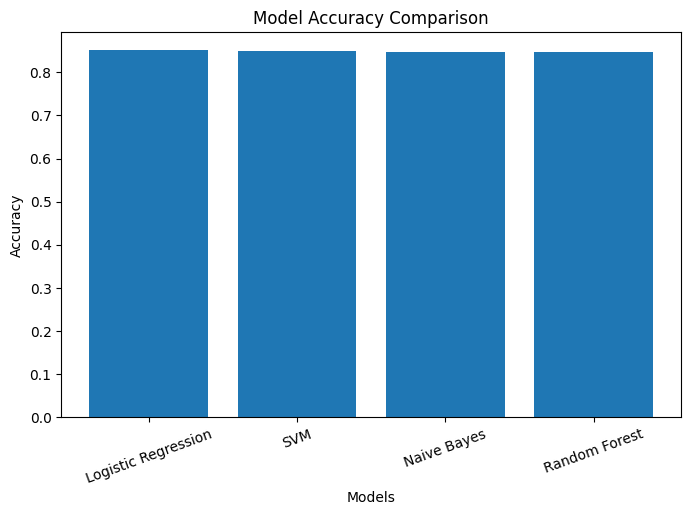

In [19]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

In [20]:
!pip install gensim

In [21]:
import gensim

In [22]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Tokenize the Text

In [23]:
sentences = df_donor['cleaned_essays'].apply(word_tokenize)

sentences.head()

,cleaned_essays
0,"[students, english, learners, working, english..."
1,"[students, arrive, school, eager, learn, polit..."
2,"[true, champions, not, always, ones, win, guts..."
3,"[work, unique, school, filled, esl, english, s..."
4,"[second, grade, classroom, next, year, made, a..."


## Word2Vec Model

In [24]:
from gensim.models import Word2Vec

word2vec_model = Word2Vec(
    sentences,
    vector_size=25,
    window=2,
    min_count=10,
    workers=4,
    epochs=3
)

## Convert Each Sentence to a Vector

In [25]:
def sentence_vector(words, model):
    vectors = [model.wv[word] for word in words if word in model.wv]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X_word2vec = np.array(
    [sentence_vector(words, word2vec_model) for words in sentences]
)

y = df_donor['project_is_approved']

In [26]:
# train test split
X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
    X_word2vec,
    y,
    test_size=0.2,
    random_state=42
)

## Logistic Regression on Word2Vec

In [27]:
lr_w2v = LogisticRegression(max_iter=1000)

lr_w2v.fit(X_train_w2v, y_train)

pred = lr_w2v.predict(X_test_w2v)

print("Word2Vec + Logistic Regression Accuracy:", accuracy_score(y_test, pred))

Word2Vec + Logistic Regression Accuracy: 0.848466819221968


## Final Comparison Table

In [28]:
comparison["Word2Vec + Logistic Regression"] = accuracy_score(y_test, pred)

print(comparison)

                 Model  Accuracy  Word2Vec + Logistic Regression
0  Logistic Regression  0.850892                        0.848467
3                  SVM  0.849382                        0.848467
1          Naive Bayes  0.848238                        0.848467
2        Random Forest  0.848238                        0.848467


## Hyperparameter Tuning GridSearchCV
## Logistic Regression

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.01,0.1,1,10]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=100),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_lr.fit(X_train,y_train)

print("Best Parameters:",grid_lr.best_params_)
print("Best Score:",grid_lr.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Best Parameters: {'C': 1}
Best Score: 0.8498363895583697


## SVM

In [30]:
param_grid = {
    'C':[0.1,1,10]
}

grid_svm = GridSearchCV(
    LinearSVC(),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_svm.fit(X_train,y_train)

print(grid_svm.best_params_)
print(grid_svm.best_score_)

{'C': 0.1}
0.8494702385068188


## ROC Curve

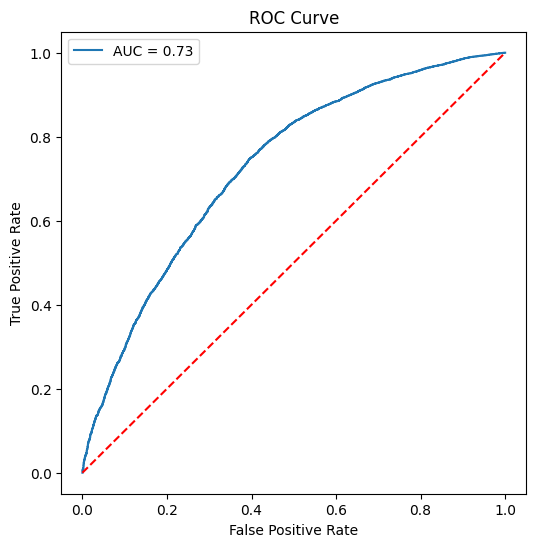

In [31]:
from sklearn.metrics import roc_curve, auc

y_score = lr.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,y_score)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,label='AUC = %0.2f'%roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Precision Recall Curve

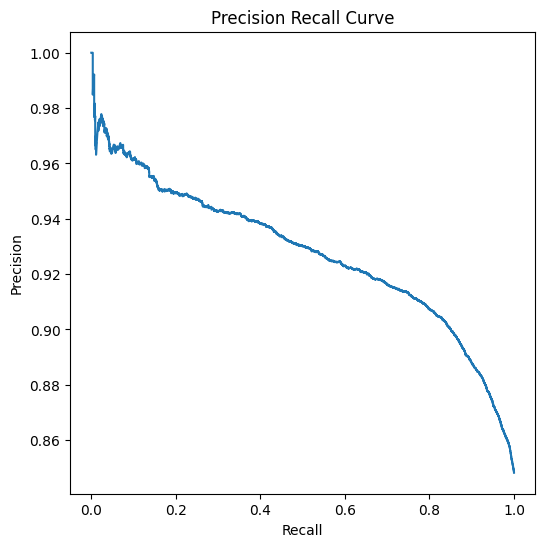

In [32]:
from sklearn.metrics import precision_recall_curve

precision,recall,_ = precision_recall_curve(y_test,y_score)

plt.figure(figsize=(6,6))
plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()

## TensorFlow

In [33]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(256,activation='relu',input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64,activation='relu'),

    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,473 (5.04 MB)

 Trainable params: 1,321,473 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# train
history = model.fit( X_train.toarray(), y_train, validation_split=0.2, epochs=10, batch_size=64 )

Epoch 1/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - accuracy: 0.8471 - loss: 0.3984 - val_accuracy: 0.8534 - val_loss: 0.3783
Epoch 2/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.8527 - loss: 0.3675 - val_accuracy: 0.8532 - val_loss: 0.3818
Epoch 3/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.8676 - loss: 0.3417 - val_accuracy: 0.8522 - val_loss: 0.3836
Epoch 4/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.9056 - loss: 0.2598 - val_accuracy: 0.8442 - val_loss: 0.4267
Epoch 5/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.9444 - loss: 0.1641 - val_accuracy: 0.8269 - val_loss: 0.5527
Epoch 6/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.9642 - loss: 0.1114 - val_accuracy: 0.8327 - val_loss: 0.6089
Epoch 7/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.9730 - loss: 0.0850 - val_accuracy: 0.8327 - val_loss: 0.6792
Epoch 8/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.9781 -

In [35]:
# evaluvate
loss,accuracy = model.evaluate(
    X_test.toarray(),
    y_test
)

print("Test Accuracy:",accuracy)

683/683 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8177 - loss: 0.7781
Test Accuracy: 0.8177116513252258


In [36]:
# prediction
pred = model.predict(X_test.toarray())

pred = (pred>0.5).astype(int)

683/683 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.36      0.26      0.30      3316
           1       0.87      0.92      0.90     18534

    accuracy                           0.82     21850
   macro avg       0.62      0.59      0.60     21850
weighted avg       0.80      0.82      0.80     21850



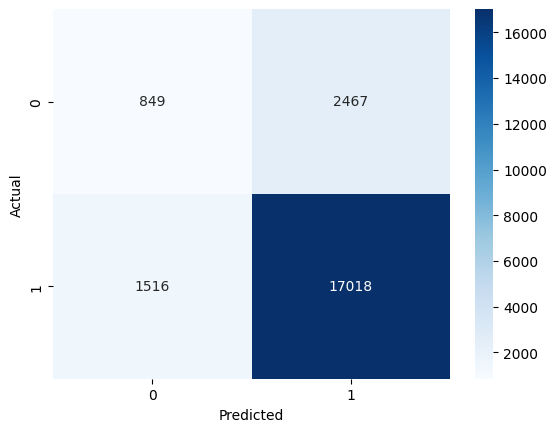

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

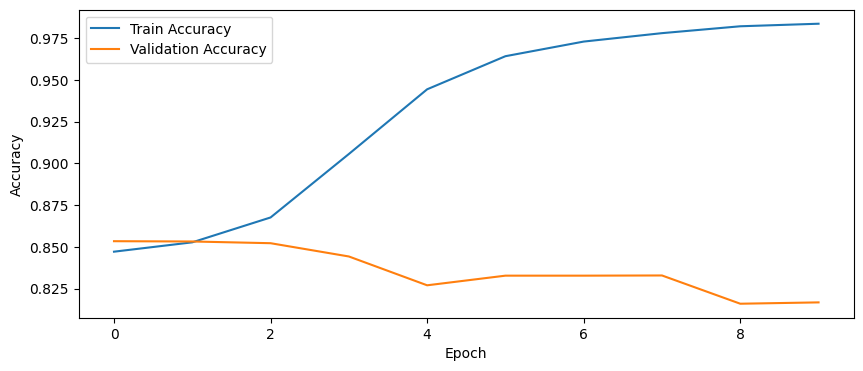

In [39]:
plt.figure(figsize=(10,4))

plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.legend()

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

In [40]:
comparison = pd.DataFrame({

'Model':[
'Logistic Regression',
'SVM',
'Random Forest',
'Deep Learning'
],

'Accuracy':[

accuracy_score(y_test,y_pred_lr),

accuracy_score(y_test,y_pred_svm),

accuracy_score(y_test,y_pred_rf),

accuracy

]

})

comparison

,Model,Accuracy
0,Logistic Regression,0.850892
1,SVM,0.849382
2,Random Forest,0.848238
3,Deep Learning,0.817712


In [41]:
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.models import Model

In [42]:
X_train_tfidf, X_test_tfidf, X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
    X,
    X_word2vec,
    y,
    test_size=0.2,
    random_state=42
)

X_train_tfidf = X_train_tfidf.toarray()
X_test_tfidf = X_test_tfidf.toarray()

In [43]:
tfidf_input = Input(shape=(X_train_tfidf.shape[1],), name="TFIDF_Input")

x1 = Dense(256, activation='relu')(tfidf_input)

x1 = Dropout(0.3)(x1)

x1 = Dense(128, activation='relu')(x1)

In [44]:
w2v_input = Input(shape=(X_train_w2v.shape[1],), name="Word2Vec_Input")

x2 = Dense(128, activation='relu')(w2v_input)

x2 = Dropout(0.3)(x2)

x2 = Dense(64, activation='relu')(x2)

In [45]:
merged = Concatenate()([x1, x2])

merged = Dense(128, activation='relu')(merged)

merged = Dropout(0.3)(merged)

merged = Dense(64, activation='relu')(merged)

output = Dense(1, activation='sigmoid')(merged)

In [46]:
model = Model(
    inputs=[tfidf_input, w2v_input],
    outputs=output
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ TFIDF_Input         │ (None, 5000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Word2Vec_Input      │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │  1,280,256 │ TFIDF_Input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │      3,328 │ Word2Vec_Input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ dense_5[0][0],    │
│ (Concatenate)       │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     24,704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         65 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,357,761 (5.18 MB)

 Trainable params: 1,357,761 (5.18 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [48]:
history = model.fit(
    [X_train_tfidf, X_train_w2v],
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.8472 - loss: 0.3977 - val_accuracy: 0.8563 - val_loss: 0.3868
Epoch 2/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.8562 - loss: 0.3633 - val_accuracy: 0.8542 - val_loss: 0.3779
Epoch 3/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.8790 - loss: 0.3168 - val_accuracy: 0.8439 - val_loss: 0.4020
Epoch 4/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9325 - loss: 0.1962 - val_accuracy: 0.8411 - val_loss: 0.4646
Epoch 5/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.9611 - loss: 0.1232 - val_accuracy: 0.8285 - val_loss: 0.5282
Epoch 6/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.9726 - loss: 0.0881 - val_accuracy: 0.8339 - val_loss: 0.6644
Epoch 7/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.9770 - loss: 0.0727 - val_accuracy: 0.8296 - val_loss: 0.6792
Epoch 8/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.9816 -

In [49]:
loss, accuracy = model.evaluate(
    [X_test_tfidf, X_test_w2v],
    y_test
)

print("Test Accuracy:", accuracy)

683/683 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8270 - loss: 0.7663
Test Accuracy: 0.8270022869110107


In [50]:
pred = model.predict(
    [X_test_tfidf, X_test_w2v]
)

pred = (pred > 0.5).astype(int)

683/683 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.38      0.21      0.27      3316
           1       0.87      0.94      0.90     18534

    accuracy                           0.83     21850
   macro avg       0.62      0.58      0.59     21850
weighted avg       0.79      0.83      0.81     21850



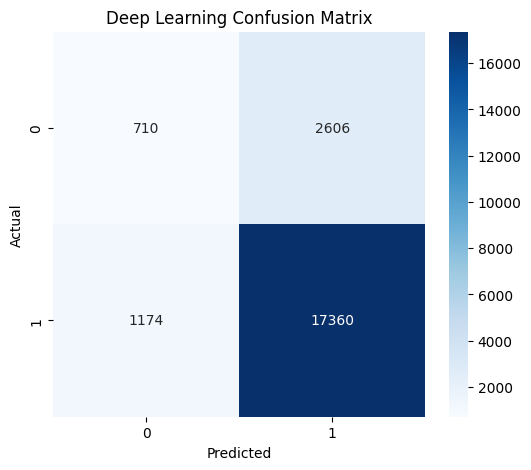

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Deep Learning Confusion Matrix")
plt.show()

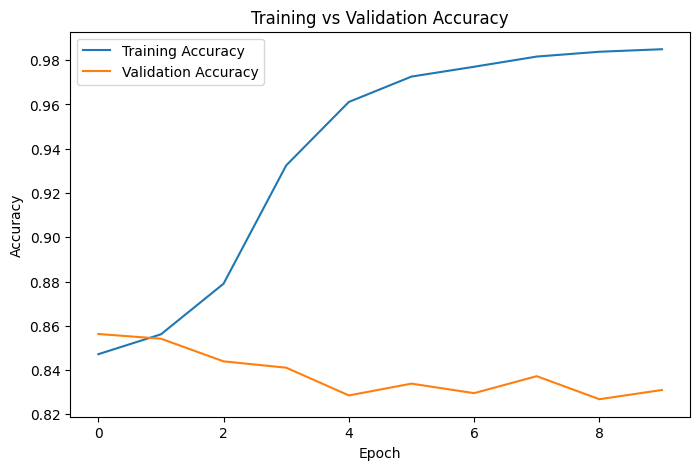

In [53]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()